In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


Train shape: (125973, 42)
Test shape: (22544, 42)


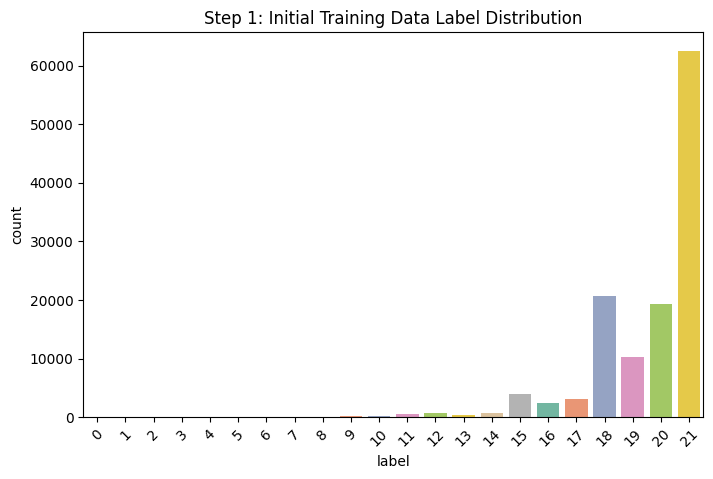

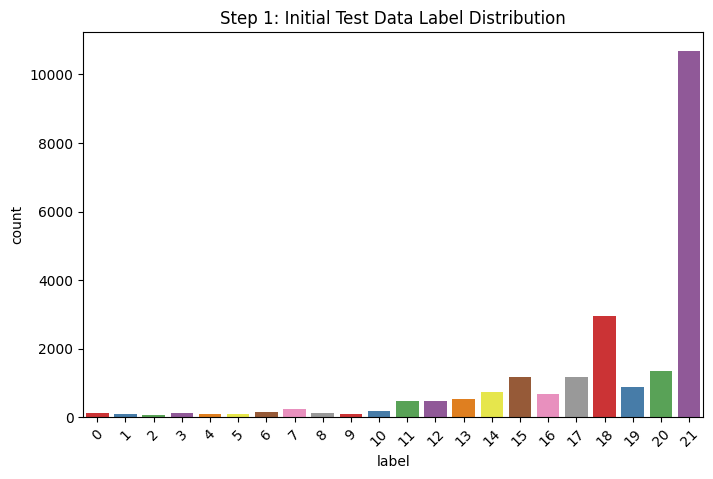

In [4]:
# Step 1: Load dataset with column names
feature_columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'
]
col_names = feature_columns + ['label']

train_path = "C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTrain+.txt"
test_path = "C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTest+.txt"

train_df = pd.read_csv(train_path, names=col_names)
test_df = pd.read_csv(test_path, names=col_names)

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

plt.figure(figsize=(8,5))
sns.countplot(x='label', data=train_df, hue='label', palette='Set2', legend=False)
plt.title('Step 1: Initial Training Data Label Distribution')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='label', data=test_df, hue='label', palette='Set1', legend=False)
plt.title('Step 1: Initial Test Data Label Distribution')
plt.xticks(rotation=45)
plt.show()

Step 2: Missing values in train: 0
Step 2: Train shape after duplicates: (124718, 42)
Step 2: Missing values in test: 0
Step 2: Test shape after duplicates: (22416, 42)


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_17004\194407053.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Train', 'Test'], y=[train_df.shape[0], test_df.shape[0]], palette='pastel')


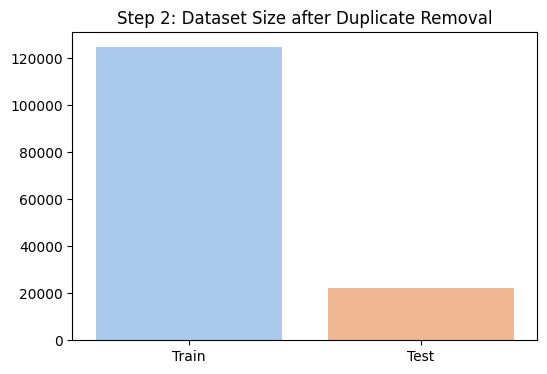

In [5]:
# Step 2: Clean missing and duplicates
print(f"Step 2: Missing values in train: {train_df.isnull().sum().sum()}")
train_df = train_df.drop_duplicates()
print(f"Step 2: Train shape after duplicates: {train_df.shape}")

print(f"Step 2: Missing values in test: {test_df.isnull().sum().sum()}")
test_df = test_df.drop_duplicates()
print(f"Step 2: Test shape after duplicates: {test_df.shape}")

plt.figure(figsize=(6,4))
sns.barplot(x=['Train', 'Test'], y=[train_df.shape[0], test_df.shape[0]], palette='pastel')
plt.title('Step 2: Dataset Size after Duplicate Removal')
plt.show()

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_17004\2514950955.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='service', data=train_df, order=train_df['service'].value_counts().index, palette='coolwarm')


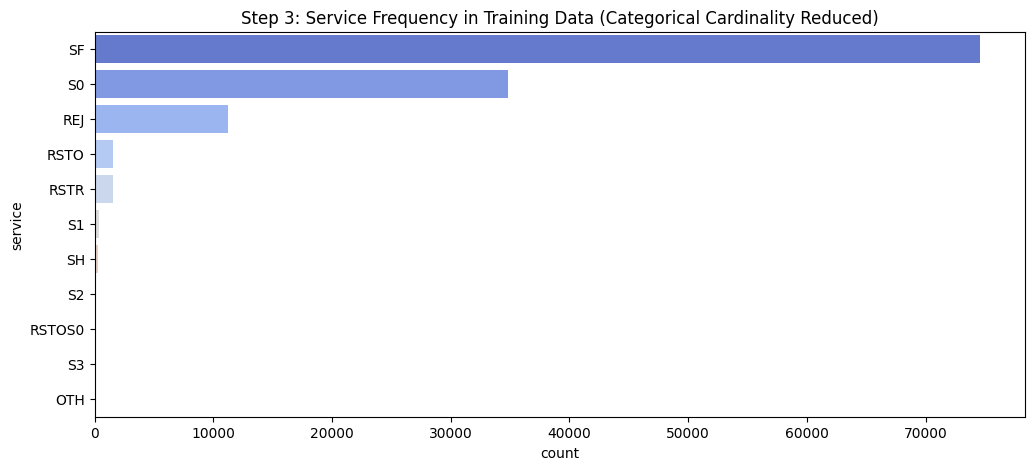

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_17004\2514950955.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='flag', data=train_df, order=train_df['flag'].value_counts().index, palette='mako')


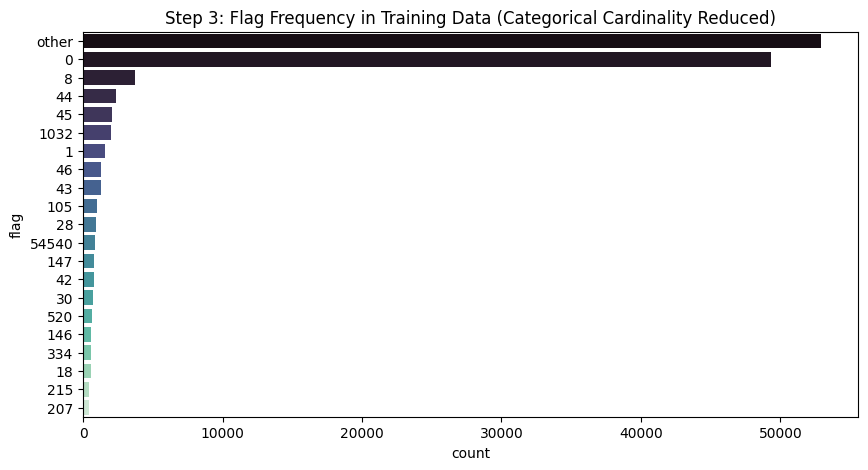

In [6]:

# Step 3: Reduce cardinality of categorical features 'service' and 'flag'
def reduce_cardinality(series, top_n):
    top_cats = series.value_counts().nlargest(top_n).index
    return series.apply(lambda x: x if x in top_cats else 'other')

train_df['service'] = reduce_cardinality(train_df['service'], 50)
test_df['service'] = test_df['service'].apply(lambda x: x if x in train_df['service'].unique() else 'other')

train_df['flag'] = reduce_cardinality(train_df['flag'], 20)
test_df['flag'] = test_df['flag'].apply(lambda x: x if x in train_df['flag'].unique() else 'other')

plt.figure(figsize=(12,5))
sns.countplot(y='service', data=train_df, order=train_df['service'].value_counts().index, palette='coolwarm')
plt.title('Step 3: Service Frequency in Training Data (Categorical Cardinality Reduced)')
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(y='flag', data=train_df, order=train_df['flag'].value_counts().index, palette='mako')
plt.title('Step 3: Flag Frequency in Training Data (Categorical Cardinality Reduced)')
plt.show()

# Convert categorical features to string before encoding
categorical_cols = ['protocol_type', 'service', 'flag']
for col in categorical_cols:
    train_df[col] = train_df[col].astype(str)
    test_df[col] = test_df[col].astype(str)



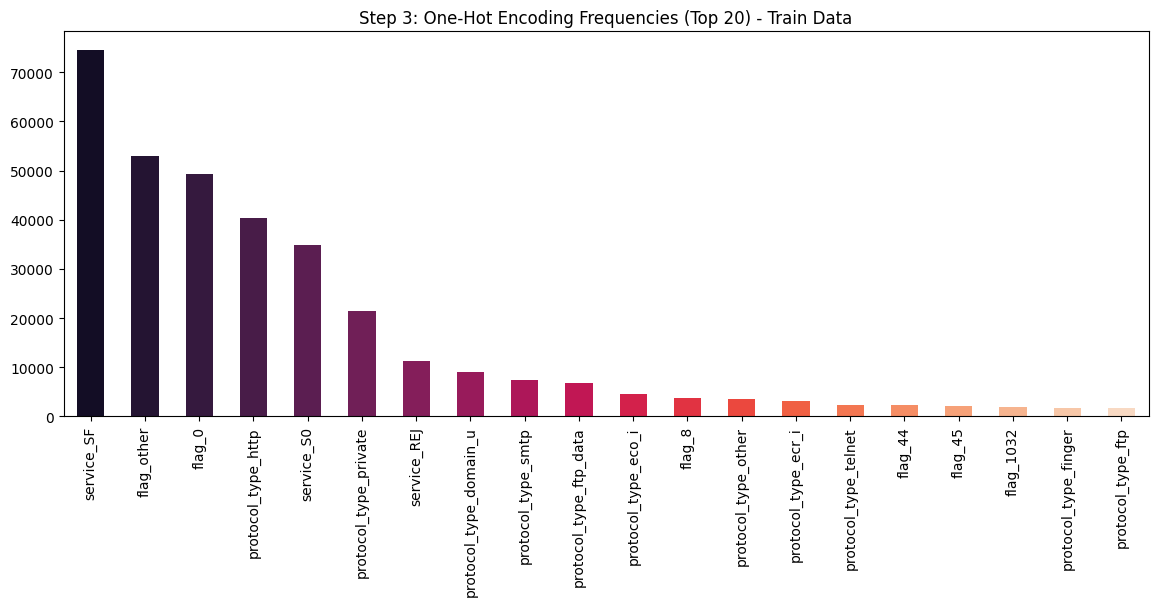

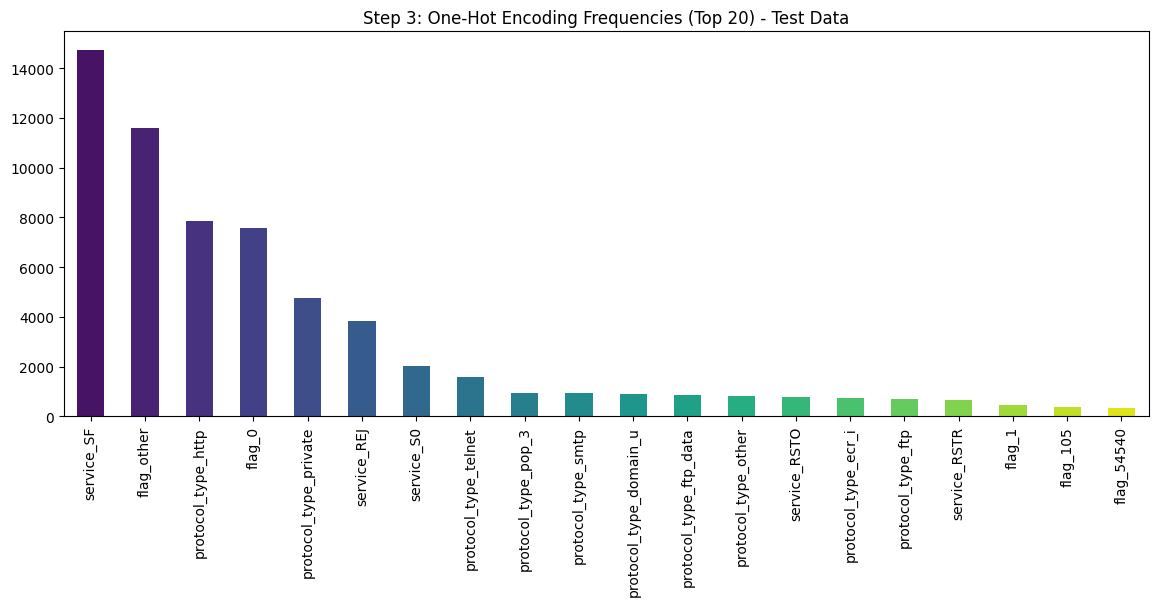

In [7]:
# Step 3 continued: One-hot encoding categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_encoded = encoder.fit_transform(train_df[categorical_cols])
test_encoded = encoder.transform(test_df[categorical_cols])
encoded_columns = encoder.get_feature_names_out(categorical_cols)

train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_columns)
test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_columns)

train_df = train_df.drop(columns=categorical_cols).reset_index(drop=True)
test_df = test_df.drop(columns=categorical_cols).reset_index(drop=True)

train_df = pd.concat([train_df, train_encoded_df], axis=1)
test_df = pd.concat([test_df, test_encoded_df], axis=1)

plt.figure(figsize=(14,5))
train_encoded_df.sum().sort_values(ascending=False).head(20).plot(kind='bar', color=sns.color_palette('rocket', 20))
plt.title('Step 3: One-Hot Encoding Frequencies (Top 20) - Train Data')
plt.show()

plt.figure(figsize=(14,5))
test_encoded_df.sum().sort_values(ascending=False).head(20).plot(kind='bar', color=sns.color_palette('viridis', 20))
plt.title('Step 3: One-Hot Encoding Frequencies (Top 20) - Test Data')
plt.show()

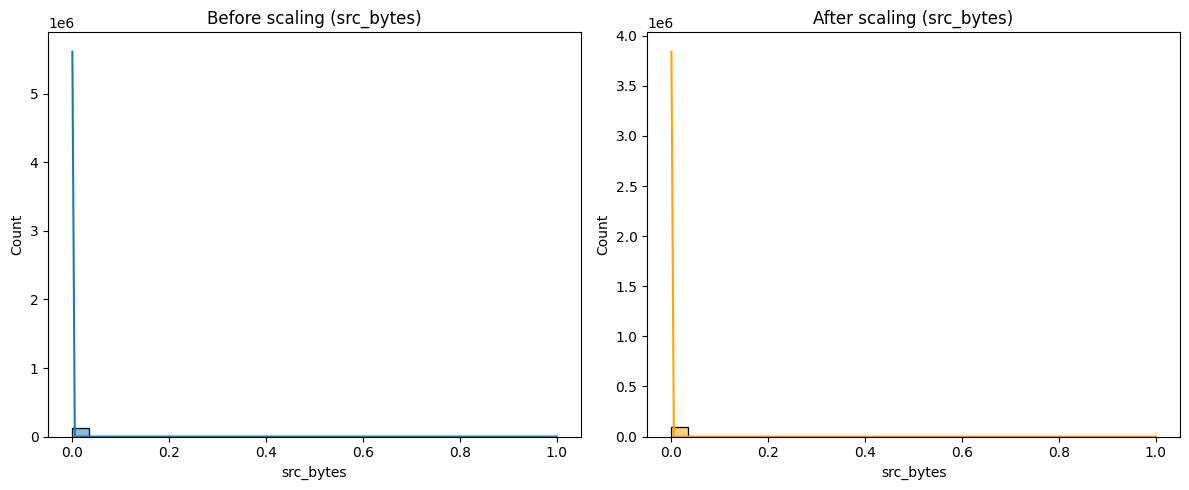

In [14]:
train_df['attack'] = train_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['attack'] = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Select numeric columns only
exclude_cols = ['label', 'attack']
features = [col for col in train_df.columns if col not in exclude_cols and train_df[col].dtype != 'object']

# Normalize features
scaler = MinMaxScaler()
train_scaled = train_df.copy()
test_scaled = test_df.copy()

train_scaled[features] = scaler.fit_transform(train_scaled[features])
test_scaled[features] = scaler.transform(test_scaled[features])

# Split train val
X = train_scaled[features]
y = train_scaled['attack']

X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(X[features[0]], bins=30, kde=True)
plt.title(f'Before scaling ({features[0]})')
plt.subplot(1,2,2)
sns.histplot(X_train[features[0]], bins=30, kde=True, color='orange')
plt.title(f'After scaling ({features[0]})')
plt.tight_layout()
plt.show()


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_17004\1808157922.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='pastel')
C:\Users\pm5cd\AppData\Local\Temp\ipykernel_17004\1808157922.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_val, palette='muted')


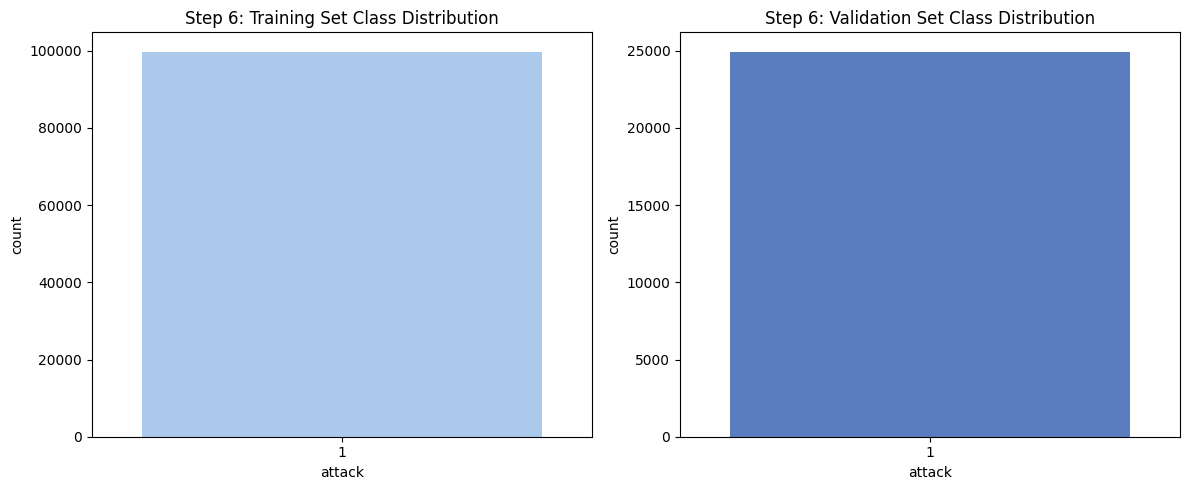

In [15]:
# Step 6: Train-validation split
X_train_val = train_scaled.drop(columns=['label', 'attack'])
y_train_val = train_scaled['attack']

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2,
                                                  stratify=y_train_val, random_state=42)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(x=y_train, palette='pastel')
plt.title('Step 6: Training Set Class Distribution')

plt.subplot(1,2,2)
sns.countplot(x=y_val, palette='muted')
plt.title('Step 6: Validation Set Class Distribution')

plt.tight_layout()
plt.show()

Train label distribution after mapping:
label
loadmodule         62238
perl               20628
rootkit            19315
spy                10283
ftp_write           3150
phf                 3073
multihop            2373
imap                 729
land                 671
buffer_overflow      641
back                 450
pod                  253
guess_passwd         191
satan                117
smurf                106
nmap                  96
teardrop              81
portsweep             79
normal                66
ipsweep               65
neptune               61
warezclient           52
Name: count, dtype: int64

Test label distribution after mapping:
label
loadmodule         10694
perl                2882
rootkit             1343
ftp_write           1176
phf                 1154
spy                  889
land                 730
multihop             670
back                 513
imap                 486
buffer_overflow      461
satan                248
pod                  195
nmap   

c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9972     22293
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22416
   macro avg     0.4973    0.5000    0.4986     22416
weighted avg     0.9891    0.9945    0.9918     22416

------------------------------------------------------------

Decision Tree Results:
              precision    recall  f1-score   support

      Attack     0.9946    0.9999    0.9972     22293
      Normal     0.5000    0.0163    0.0315       123

    accuracy                         0.9945     22416
   macro avg     0.7473    0.5081    0.5144     22416
weighted avg     0.9919    0.9945    0.9919     22416

------------------------------------------------------------

Random Forest Results:


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9972     22293
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22416
   macro avg     0.4973    0.5000    0.4986     22416
weighted avg     0.9891    0.9945    0.9918     22416

------------------------------------------------------------

Support Vector Machine Results:


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9972     22293
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22416
   macro avg     0.4973    0.5000    0.4986     22416
weighted avg     0.9891    0.9945    0.9918     22416

------------------------------------------------------------

K-Nearest Neighbors Results:
              precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9972     22293
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22416
   macro avg     0.4973    0.5000    0.4986     22416
weighted avg     0.9891    0.9945    0.9918     22416

------------------------------------------------------------


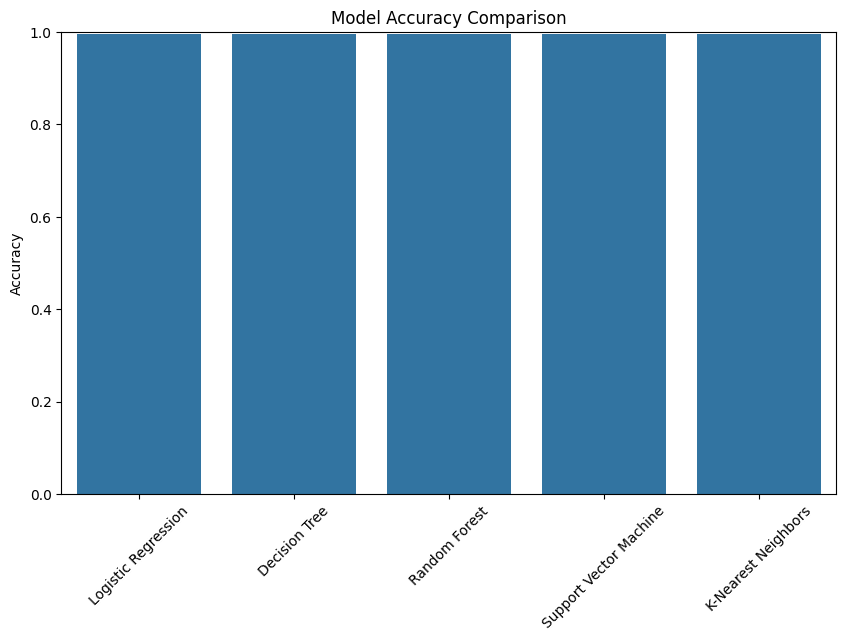

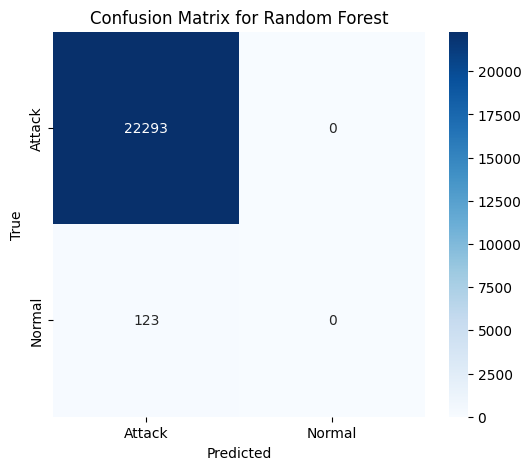

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Column names as per NSL-KDD dataset
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
    "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", 
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login",
    "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate", 
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"
]

# File paths
train_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTrain+.txt'
test_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTest+.txt'

# Load datasets
train_df = pd.read_csv(train_file, names=column_names)
test_df = pd.read_csv(test_file, names=column_names)

# Numeric label codes mapping to class names
# Note: Adjust this dictionary according to your dataset documentation
label_map = {
    0: 'normal',
    1: 'neptune',
    2: 'warezclient',
    3: 'ipsweep',
    4: 'portsweep',
    5: 'teardrop',
    6: 'nmap',
    7: 'satan',
    8: 'smurf',
    9: 'guess_passwd',
    10: 'pod',
    11: 'buffer_overflow',
    12: 'imap',
    13: 'back',
    14: 'land',
    15: 'ftp_write',
    16: 'multihop',
    17: 'phf',
    18: 'perl',
    19: 'spy',
    20: 'rootkit',
    21: 'loadmodule'
    # Add all labels if dataset uses different numeric codes
}

# Map labels in train and test datasets
train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

# Remove duplicates
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

# Verify label presence
print("Train label distribution after mapping:")
print(train_df['label'].value_counts())

print("\nTest label distribution after mapping:")
print(test_df['label'].value_counts())

# Create binary labels
train_df['binary_label'] = train_df['label'].apply(lambda x: 'Normal' if x == 'normal' else 'Attack')
test_df['binary_label'] = test_df['label'].apply(lambda x: 'Normal' if x == 'normal' else 'Attack')

print("\nTrain binary class distribution:")
print(train_df['binary_label'].value_counts())

print("\nTest binary class distribution:")
print(test_df['binary_label'].value_counts())

# Separate features and targets
X_train = train_df.drop(['label', 'binary_label'], axis=1)
y_train = train_df['binary_label']
X_test = test_df.drop(['label', 'binary_label'], axis=1)
y_test = test_df['binary_label']

# Define categorical and numeric features
categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [col for col in X_train.columns if col not in categorical_features]

# Convert numeric columns to numeric types
for col in numeric_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

X_train[numeric_features] = X_train[numeric_features].fillna(0)
X_test[numeric_features] = X_test[numeric_features].fillna(0)

# Preprocessing pipeline with memory-efficient sparse encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Define ML models
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Support Vector Machine': SVC(probability=True),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_test_processed)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n{name} Results:")
    print(classification_report(y_test, preds, digits=4))
    print("-" * 60)

# Plot accuracy comparison
plt.figure(figsize=(10,6))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()

# Confusion matrix for best model (random forest here)
best_model = models['Random Forest']
preds_best = best_model.predict(X_test_processed)
cm = confusion_matrix(y_test, preds_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Attack', 'Normal'], yticklabels=['Attack', 'Normal'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Random Forest')
plt.show()


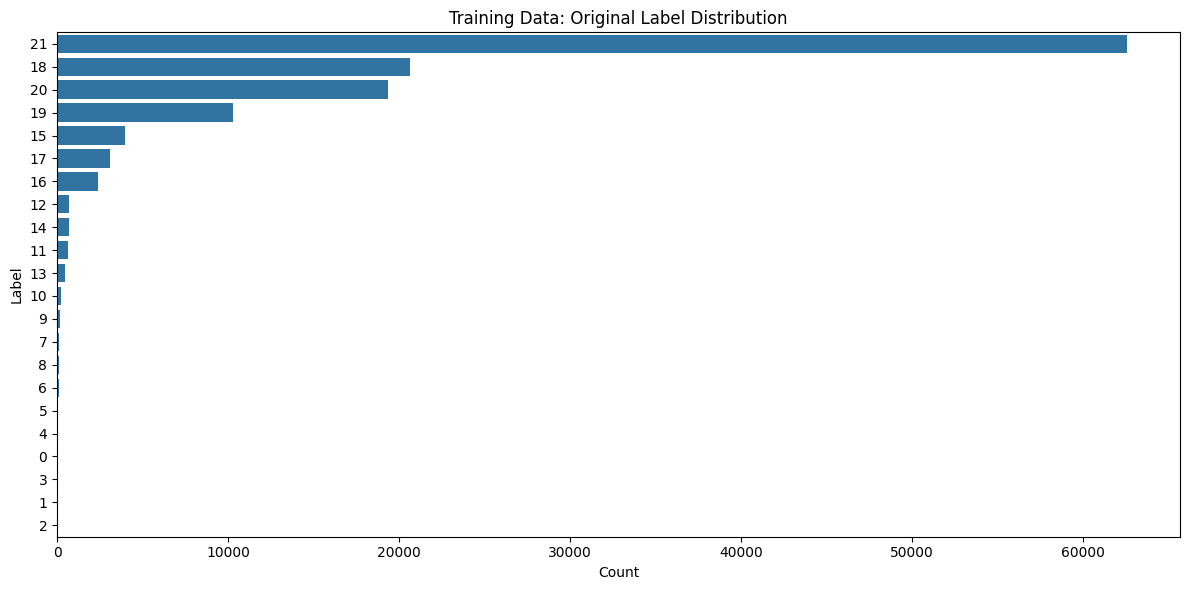

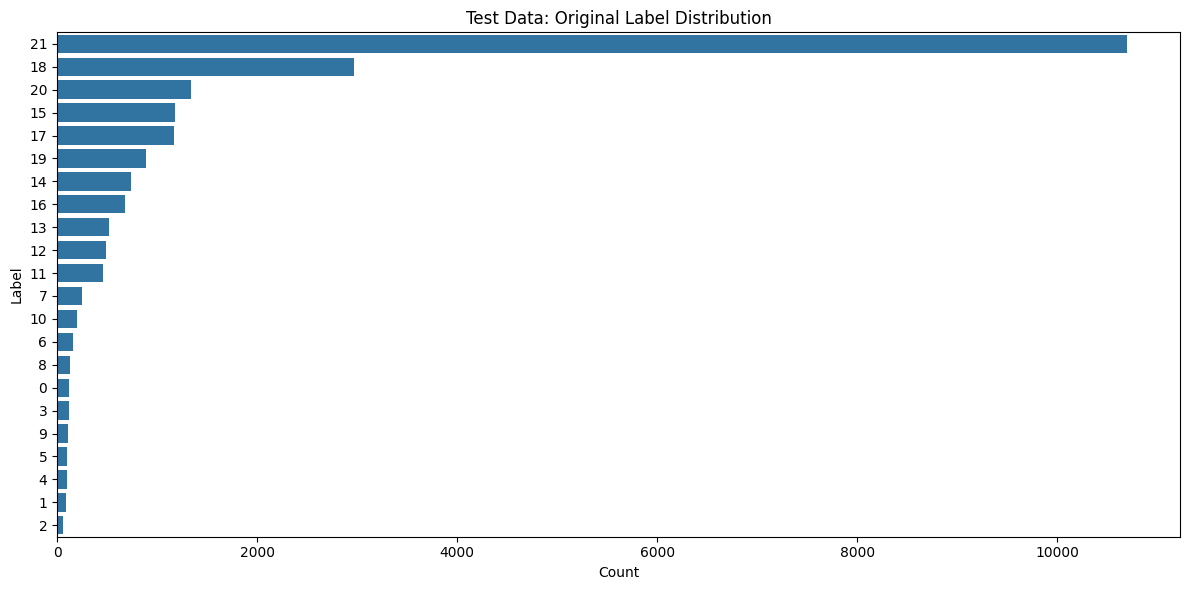

Missing label mappings in train: 0


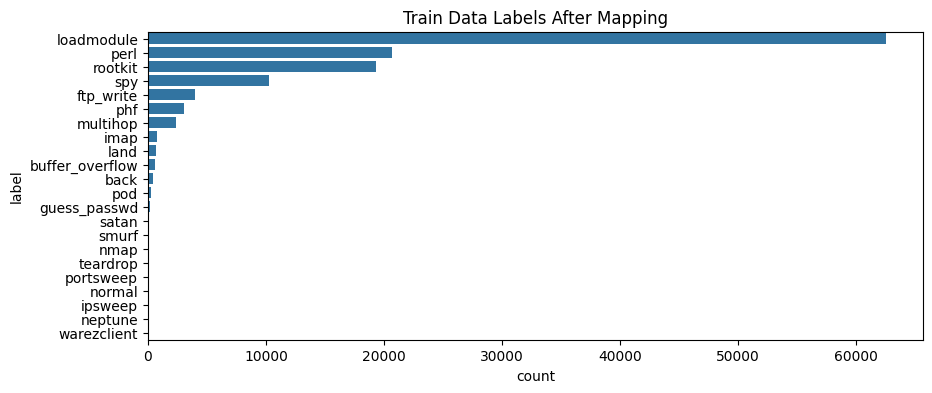

Missing label mappings in test: 0


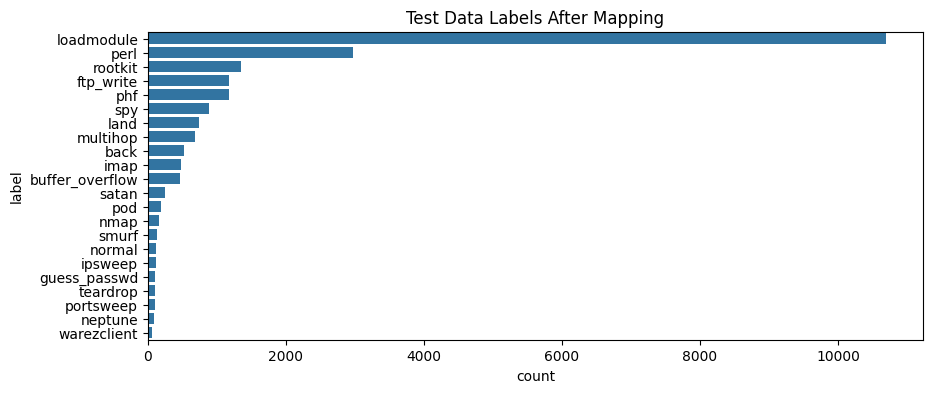

Train duplicates before: 1255
Train duplicates after: 0
Test duplicates before: 128
Test duplicates after: 0


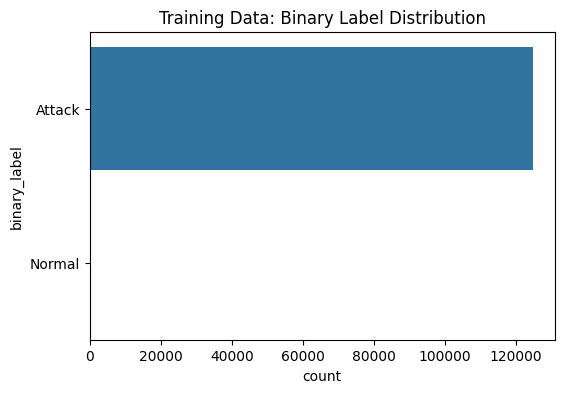

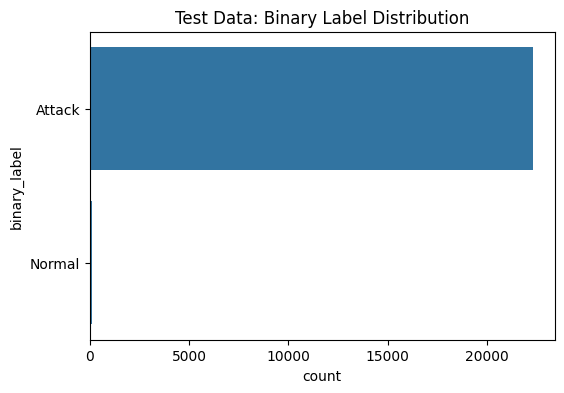

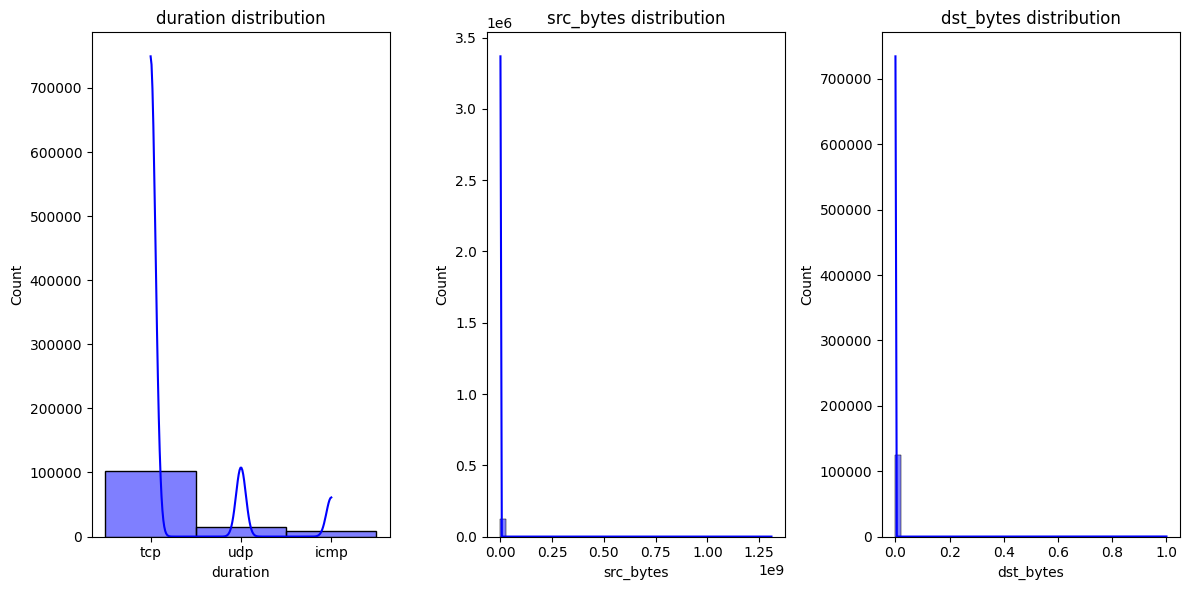

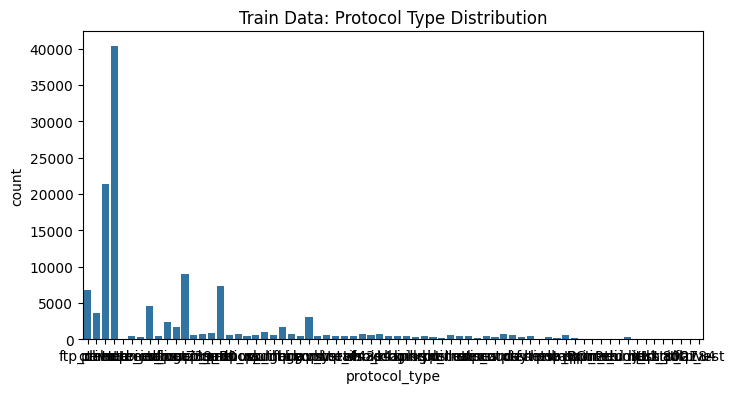


Training Logistic Regression...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logistic Regression classification report:
               precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9972     22293
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22416
   macro avg     0.4973    0.5000    0.4986     22416
weighted avg     0.9891    0.9945    0.9918     22416


Training Decision Tree...
Decision Tree classification report:
               precision    recall  f1-score   support

      Attack     0.9946    0.9999    0.9972     22293
      Normal     0.5000    0.0163    0.0315       123

    accuracy                         0.9945     22416
   macro avg     0.7473    0.5081    0.5144     22416
weighted avg     0.9919    0.9945    0.9919     22416


Training Random Forest...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Random Forest classification report:
               precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9972     22293
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22416
   macro avg     0.4973    0.5000    0.4986     22416
weighted avg     0.9891    0.9945    0.9918     22416


Training Support Vector Machine...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Support Vector Machine classification report:
               precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9972     22293
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22416
   macro avg     0.4973    0.5000    0.4986     22416
weighted avg     0.9891    0.9945    0.9918     22416


Training K-Nearest Neighbors...
K-Nearest Neighbors classification report:
               precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9972     22293
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22416
   macro avg     0.4973    0.5000    0.4986     22416
weighted avg     0.9891    0.9945    0.9918     22416



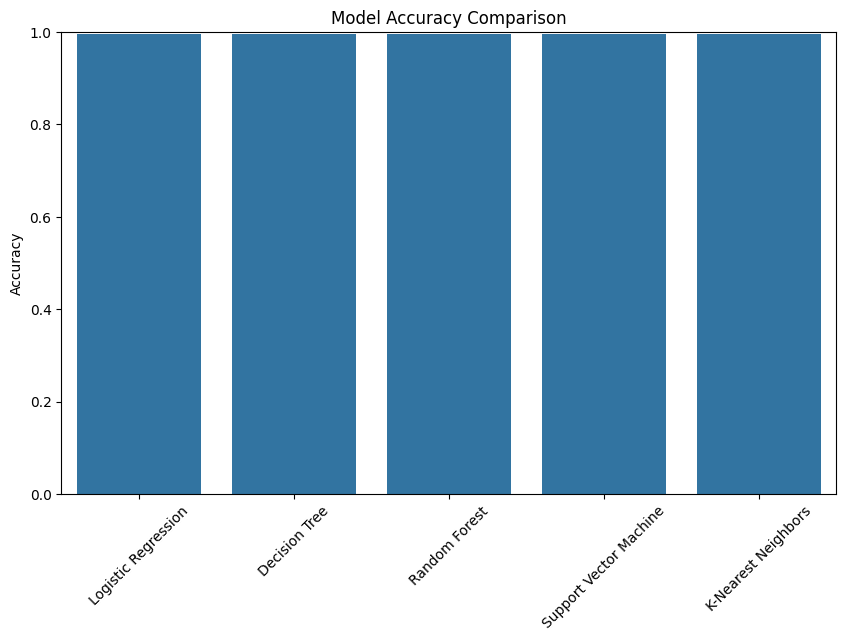

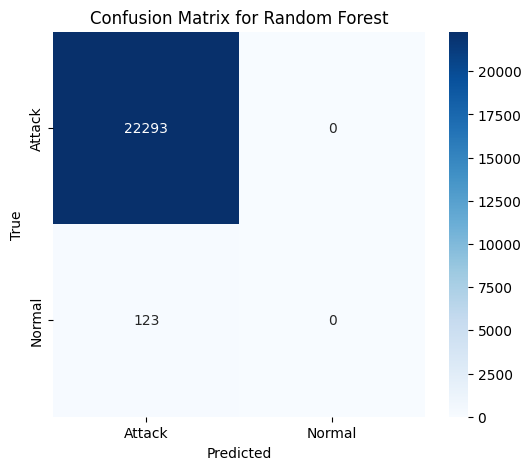

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Column names as per NSL-KDD dataset
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
    "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login",
    "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"
]

# File paths (update as necessary)
train_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTrain+.txt'
test_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTest+.txt'

# Load datasets
train_df = pd.read_csv(train_file, names=column_names)
test_df = pd.read_csv(test_file, names=column_names)

# Data visualization - original label distribution in train
plt.figure(figsize=(12,6))
sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index)
plt.title('Training Data: Original Label Distribution')
plt.xlabel('Count')
plt.ylabel('Label')
plt.tight_layout()
plt.show()

# Data visualization - original label distribution in test
plt.figure(figsize=(12,6))
sns.countplot(y=test_df['label'], order=test_df['label'].value_counts().index)
plt.title('Test Data: Original Label Distribution')
plt.xlabel('Count')
plt.ylabel('Label')
plt.tight_layout()
plt.show()

# Numeric label codes mapping to class names (adjust this mapping to your dataset)
label_map = {
    0: 'normal', 1: 'neptune', 2: 'warezclient', 3: 'ipsweep', 4: 'portsweep', 5: 'teardrop',
    6: 'nmap', 7: 'satan', 8: 'smurf', 9: 'guess_passwd', 10: 'pod', 11: 'buffer_overflow',
    12: 'imap', 13: 'back', 14: 'land', 15: 'ftp_write', 16: 'multihop', 17: 'phf', 18: 'perl',
    19: 'spy', 20: 'rootkit', 21: 'loadmodule'
}

# Map numeric labels to text labels
train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

# Check for missing mappings and visualize
print("Missing label mappings in train:", train_df['label'].isna().sum())
plt.figure(figsize=(10,4))
sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index)
plt.title('Train Data Labels After Mapping')
plt.show()

print("Missing label mappings in test:", test_df['label'].isna().sum())
plt.figure(figsize=(10,4))
sns.countplot(y=test_df['label'], order=test_df['label'].value_counts().index)
plt.title('Test Data Labels After Mapping')
plt.show()

# Drop duplicates and visualize counts before and after
print(f"Train duplicates before: {train_df.duplicated().sum()}")
train_df.drop_duplicates(inplace=True)
print(f"Train duplicates after: {train_df.duplicated().sum()}")

print(f"Test duplicates before: {test_df.duplicated().sum()}")
test_df.drop_duplicates(inplace=True)
print(f"Test duplicates after: {test_df.duplicated().sum()}")

# Binary label creation visualization
train_df['binary_label'] = train_df['label'].apply(lambda x: 'Normal' if x == 'normal' else 'Attack')
test_df['binary_label'] = test_df['label'].apply(lambda x: 'Normal' if x == 'normal' else 'Attack')

plt.figure(figsize=(6,4))
sns.countplot(train_df['binary_label'])
plt.title('Training Data: Binary Label Distribution')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(test_df['binary_label'])
plt.title('Test Data: Binary Label Distribution')
plt.show()

# Split features and target
X_train = train_df.drop(['label', 'binary_label'], axis=1)
y_train = train_df['binary_label']
X_test = test_df.drop(['label', 'binary_label'], axis=1)
y_test = test_df['binary_label']

# List categorical and numeric features
categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [col for col in X_train.columns if col not in categorical_features]

# Visualize numerical feature distributions (example with few selected)
plt.figure(figsize=(12,6))
for i, col in enumerate(['duration', 'src_bytes', 'dst_bytes']):
    plt.subplot(1,3,i+1)
    sns.histplot(X_train[col], bins=50, kde=True, color='blue')
    plt.title(f'{col} distribution')
plt.tight_layout()
plt.show()

# Visualize categorical feature value counts for 'protocol_type'
plt.figure(figsize=(8,4))
sns.countplot(x='protocol_type', data=X_train)
plt.title('Train Data: Protocol Type Distribution')
plt.show()

# Convert numeric columns to numeric and fill missing values
for col in numeric_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

X_train[numeric_features] = X_train[numeric_features].fillna(0)
X_test[numeric_features] = X_test[numeric_features].fillna(0)

# Preprocessing pipeline: scaling numericals, encoding categoricals with sparse output
preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Support Vector Machine': SVC(probability=True),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Training and evaluation with model performance visualization
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_test_processed)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name} classification report:\n", classification_report(y_test, preds, digits=4))

# Accuracy comparison plot
plt.figure(figsize=(10,6))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()

# Confusion matrix heatmap for Random Forest
best_model = models['Random Forest']
preds_best = best_model.predict(X_test_processed)
cm = confusion_matrix(y_test, preds_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Attack', 'Normal'], yticklabels=['Attack', 'Normal'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Random Forest')
plt.show()
